In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd
import statsmodels.api as sm

import seaborn as sns

path = '/media/fkaiser/'

sys.path.append('../power_system_split/')
#sys.path.append('./')
import utils,visualisation

# Evaluate component cluster for CO$_2$ levels together

## Setup and load graph

In [5]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2l_list = co2ls = np.arange(0.0,0.99,0.05)

n_subset_solutions = -1 # number of random sampled time steps from each co2 level simulation, -1 means all

In [6]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)


/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [7]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)

if n_subset_solutions==-1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps

## Load clustering results

In [8]:
indicator_vectors = np.load(cluster_results_path + 'indicator_vectors_all_co2level_{}_based.npy'.format(criterion))
component_props = pd.read_hdf(cluster_results_path + 'split_component_properties_all_co2level_{}_based.h5'.format(criterion))

INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [10]:
indicator_vectors

array([[ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False]])

In [70]:
cluster_result_name = 'cluster_label_db_mdist{:.3}'.format(9./ len(G))

print('Number of cluster (including noise-cluster in dbscan):', component_props.loc[:,cluster_result_name].unique().size)
component_props.head()

Number of cluster (including noise-cluster in dbscan): 76


,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation,cluster_label_agg_mdist0.0312,cluster_label_agg_mdist0.0148,cluster_label_db_mdist0.0312,cluster_label_db_mdist0.0148,rocof,number_of_nodes,rocof_positive
0,0.0,01_10_2013_00,0.0,68714.224579,-4684.991113,NaN,9,150,0,0,0.068181,593,False
1,0.0,01_10_2013_00,0.0,0.000000,4685.012622,NaN,1,29,1,1,NaN,15,False
2,0.0,01_10_2013_00,6.0,68714.224579,-4754.473726,NaN,9,150,0,0,0.069192,587,False
3,0.0,01_10_2013_00,6.0,0.000000,4754.495235,NaN,1,29,1,1,NaN,21,False
4,0.0,01_10_2013_00,9.0,68222.224579,-6624.262287,NaN,9,150,0,0,0.097098,584,False


## Add component and cluster properties 

In [71]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)

# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby([cluster_result_name,'co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby([cluster_result_name,'co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby([cluster_result_name,'co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby([cluster_result_name,'co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()


# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby([cluster_result_name,'co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].mean()
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].median().abs()
cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].mean().abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label_db_mdist0.0148 co2l                                             
-1                           0.00     208    0.000075            330.721154   
                             0.05     124    0.000044            254.338710   
                             0.10      71    0.000025            268.408451   
                             0.15      60    0.000021            256.150000   
                             0.20      29    0.000010            255.275862   

                                   number_pos_inf_rocofs  \
cluster_label_db_mdist0.0148 co2l                          
-1                           0.00                      0   
                             0.05                      0   
                             0.10                      0   
                             0.15                      0   
                             0.20                      0   

                                   number_neg_inf_rocofs  median_rocof  \
cluster_label_db_mdist0.0148 co2l                                        
-1                           0.00                      0     -0.280072   
                             0.05                      0      0.162383   
                             0.10                      0     -0.126966   
                             0.15                      0     -0.100474   
                             0.20                      0      0.078682   

                                   median_pos_rocof  mean_pos_rocof  \
cluster_label_db_mdist0.0148 co2l                                     
-1                           0.00          2.423991       21.922311   
                             0.05          2.367821      136.301559   
                             0.10          1.415013        9.626273   
                             0.15          1.231895        5.166255   
                             0.20          0.769203        5.501209   

                                   min_pos_rocof  max_pos_rocof  \
cluster_label_db_mdist0.0148 co2l                                 
-1                           0.00       0.059790      81.168316   
                             0.05       0.205139    1397.366008   
                             0.10       0.343007      56.038606   
                             0.15       0.185303       7.804835   
                             0.20       0.053910      19.452912   

                                   median_neg_rocof  mean_neg_rocof  \
cluster_label_db_mdist0.0148 co2l                                     
-1                           0.00          0.394274        2.153928   
                             0.05          0.404660        1.937633   
                             0.10          0.259268        3.535734   
                             0.15          0.276447        0.923946   
                             0.20          0.179273        0.416956   

                                   max_neg_rocof  min_neg_rocof  
cluster_label_db_mdist0.0148 co2l                                
-1                           0.00       6.901551       0.061993  
                             0.05       3.241772       0.148780  
                             0.10      11.317953       0.146052  
                             0.15       1.348160       0.074015  
                             0.20       1.330335       0.074834

## Select a few cluster for analysis

In [72]:
# Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p= 0.0005
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if not more than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values(cluster_result_name).unique().size

selected_cluster_mask = cluster_props.groupby(cluster_result_name).apply(lambda x: (x.counts>=max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if not more than 1458 hits in all 2791520 simulations
Labels of selected cluster: Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 9, 10], dtype='int64', name='cluster_label_db_mdist0.0148')
Number of selected cluster: 10


## Plot cluster on map

<AxesSubplot:xlabel='cluster_label_db_mdist0.0148'>

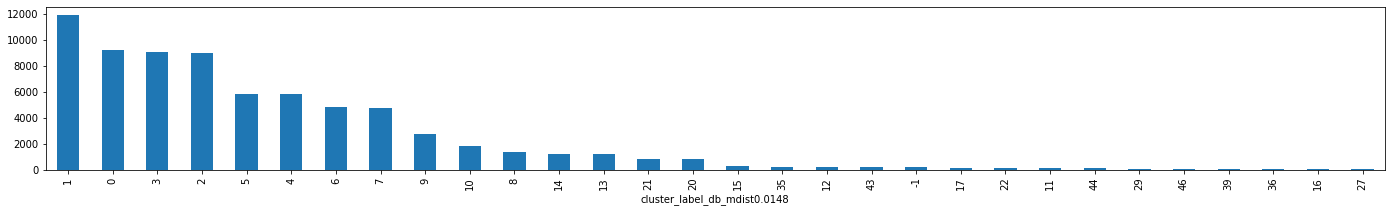

In [73]:
cluster_props.groupby(cluster_result_name).apply(lambda x: x.counts.max()).sort_values().iloc[::-1].iloc[:30].plot.bar(figsize=(24,3))

# check how fast cluster probabilities decrease and for how much cases the selected ones account for

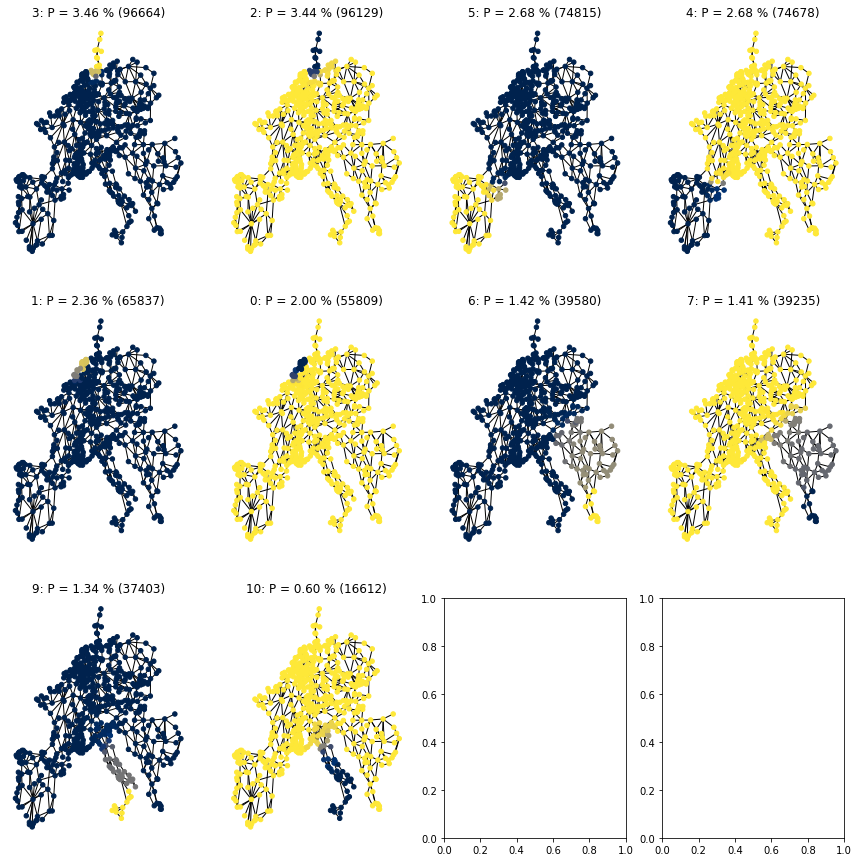

In [74]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(15,15))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.loc[:, cluster_result_name].isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.loc[:, cluster_result_name].isin(selected_cluster)].loc[:,cluster_result_name]
selected_cluster_props = cluster_props.loc[:,['likelihood', 'counts']].groupby(cluster_result_name).sum()
selected_cluster_props = selected_cluster_props[selected_cluster_props.index.isin(selected_cluster_labels)]

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     selected_cluster_props,
                                     G)

## Infinite Rocofs

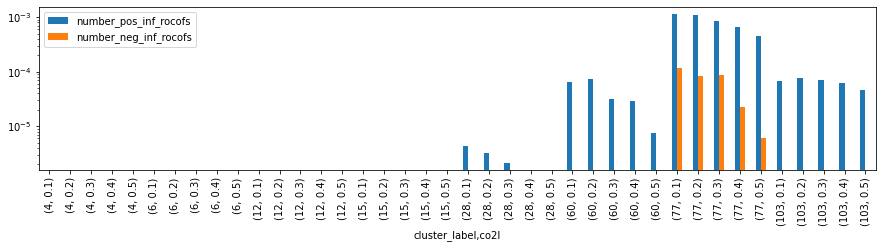

In [15]:
# Display number of infinite rocofs
cluster_props.loc[selected_cluster,['number_pos_inf_rocofs', 'number_neg_inf_rocofs']].div(number_of_simulations).plot.bar(figsize=(15,3))
plt.yscale('log')

## Dependence on CO$_2$ level

In [66]:
#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,[cluster_result_name, 'co2l']]).isin(selected_cluster)
#selected_components = component_props[selected_components_mask]

selected_components = component_props[component_props.loc[:,cluster_result_name].isin(selected_cluster)]

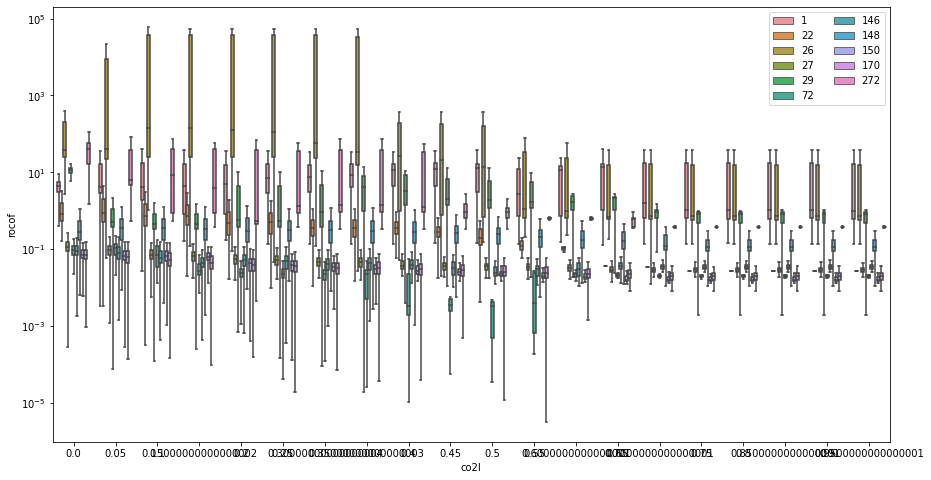

In [67]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[selected_components.rocof_positive], x='co2l', y='rocof', hue=cluster_result_name, showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

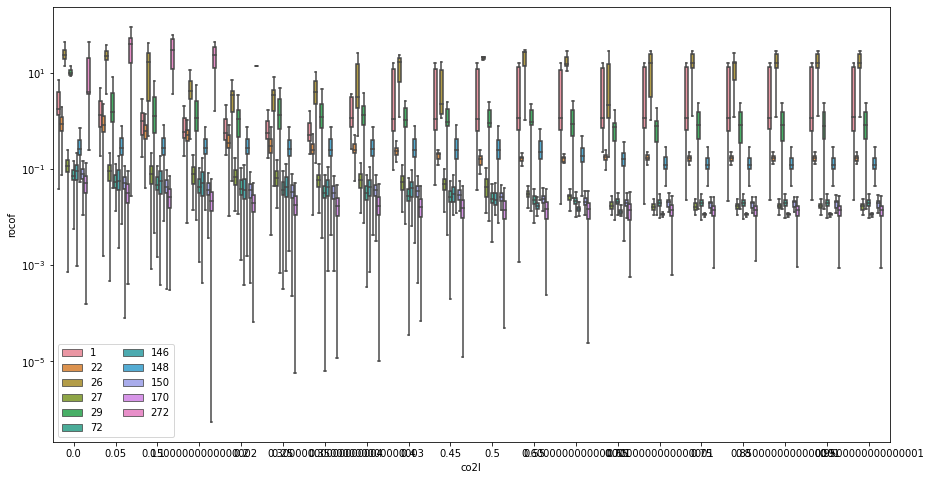

In [69]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[~selected_components.rocof_positive], x='co2l', y='rocof', hue=cluster_result_name, showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

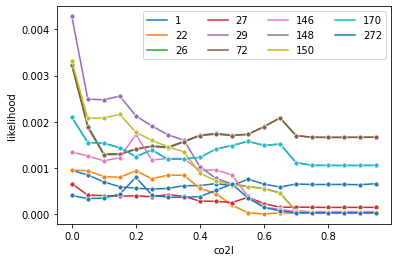

In [54]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='likelihood', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
#plt.yscale('log')
plt.legend(ncol=4)

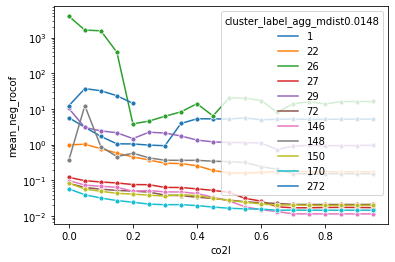

In [55]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_neg_rocof', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
plt.yscale('log')

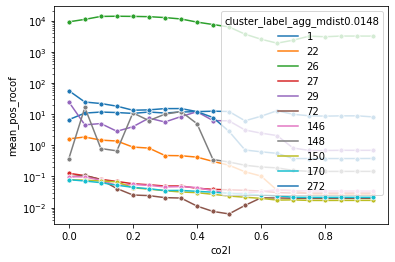

In [56]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_pos_rocof', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
plt.yscale('log')

<AxesSubplot:xlabel='co2l', ylabel='number_neg_inf_rocofs'>

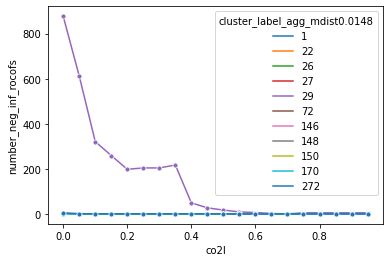

In [60]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='number_neg_inf_rocofs', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
#plt.yscale('log')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

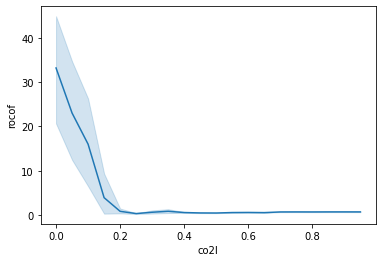

In [61]:
sns.lineplot(data=component_props[~component_props.rocof_positive] , x='co2l', y='rocof')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

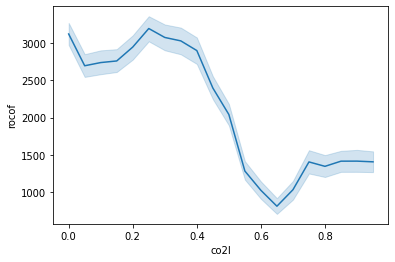

In [62]:
sns.lineplot(data=component_props[component_props.rocof_positive] , x='co2l', y='rocof')

In [63]:
component_props

,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation,cluster_label_agg_mdist0.0312,cluster_label_agg_mdist0.0148,cluster_label_db_mdist0.0312,cluster_label_db_mdist0.0148,rocof,number_of_nodes,rocof_positive
0,0.00,01_10_2013_00,0.0,68714.224579,-4684.991113,NaN,9,150,0,0,0.068181,593,False
1,0.00,01_10_2013_00,0.0,0.000000,4685.012622,NaN,1,29,1,1,NaN,15,False
2,0.00,01_10_2013_00,6.0,68714.224579,-4754.473726,NaN,9,150,0,0,0.069192,587,False
3,0.00,01_10_2013_00,6.0,0.000000,4754.495235,NaN,1,29,1,1,NaN,21,False
4,0.00,01_10_2013_00,9.0,68222.224579,-6624.262287,NaN,9,150,0,0,0.097098,584,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
674718,0.95,31_12_2013_21,20.0,835.773487,-2152.558064,NaN,86,1,8,9,2.575528,11,False
674719,0.95,31_12_2013_21,27.0,193094.614149,-4007.117466,NaN,22,72,2,2,0.020752,590,False
674720,0.95,31_12_2013_21,27.0,240.930000,4007.135290,NaN,1,26,1,3,16.631948,18,True
674721,0.95,31_12_2013_21,28.0,193146.514149,-4039.986507,NaN,22,72,2,2,0.020917,591,False


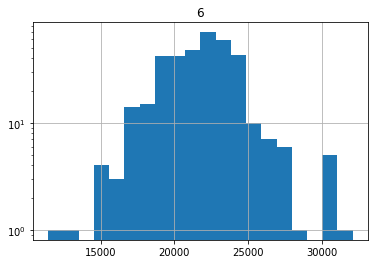

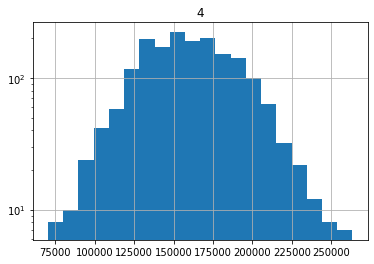

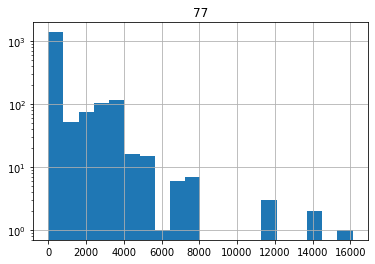

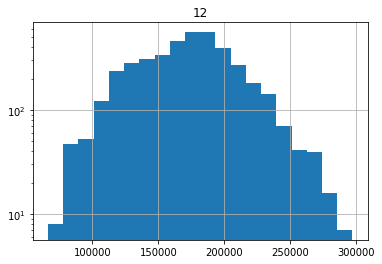

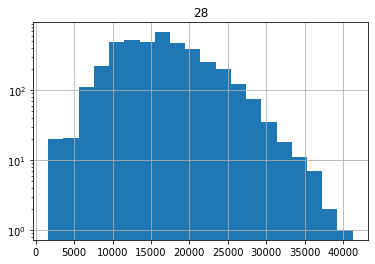

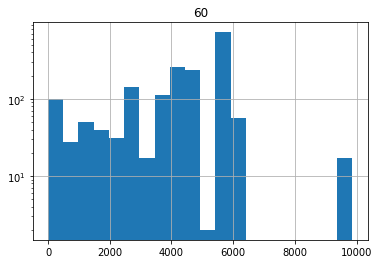

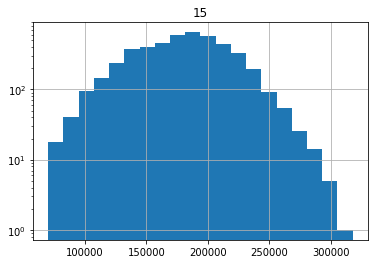

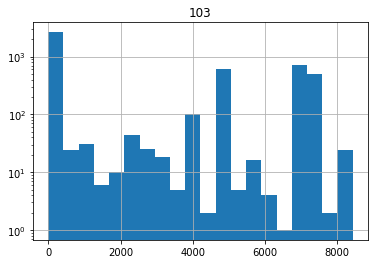

In [34]:
for label in selected_cluster_labels.unique():
    plt.figure()
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.5)].inertia_proxy.hist(log=True, bins=20)
    plt.title(label)
    
# plot: für jeden cluster 2 co2l visualisieren und mit der gesamt verteilung (über die zeit) vergleichen